Target Run ID: 20251130_153500
Output Directory: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3
Created directory: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3
Merged Samples: 1046
Calculating metrics...
Saved CSV: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3/metrics_ohfp_composition6_full.csv
Generating Figure...
Saved Figure: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3/FigC_Bidirectional_Composite_Correlation.png

✅ All Finished.


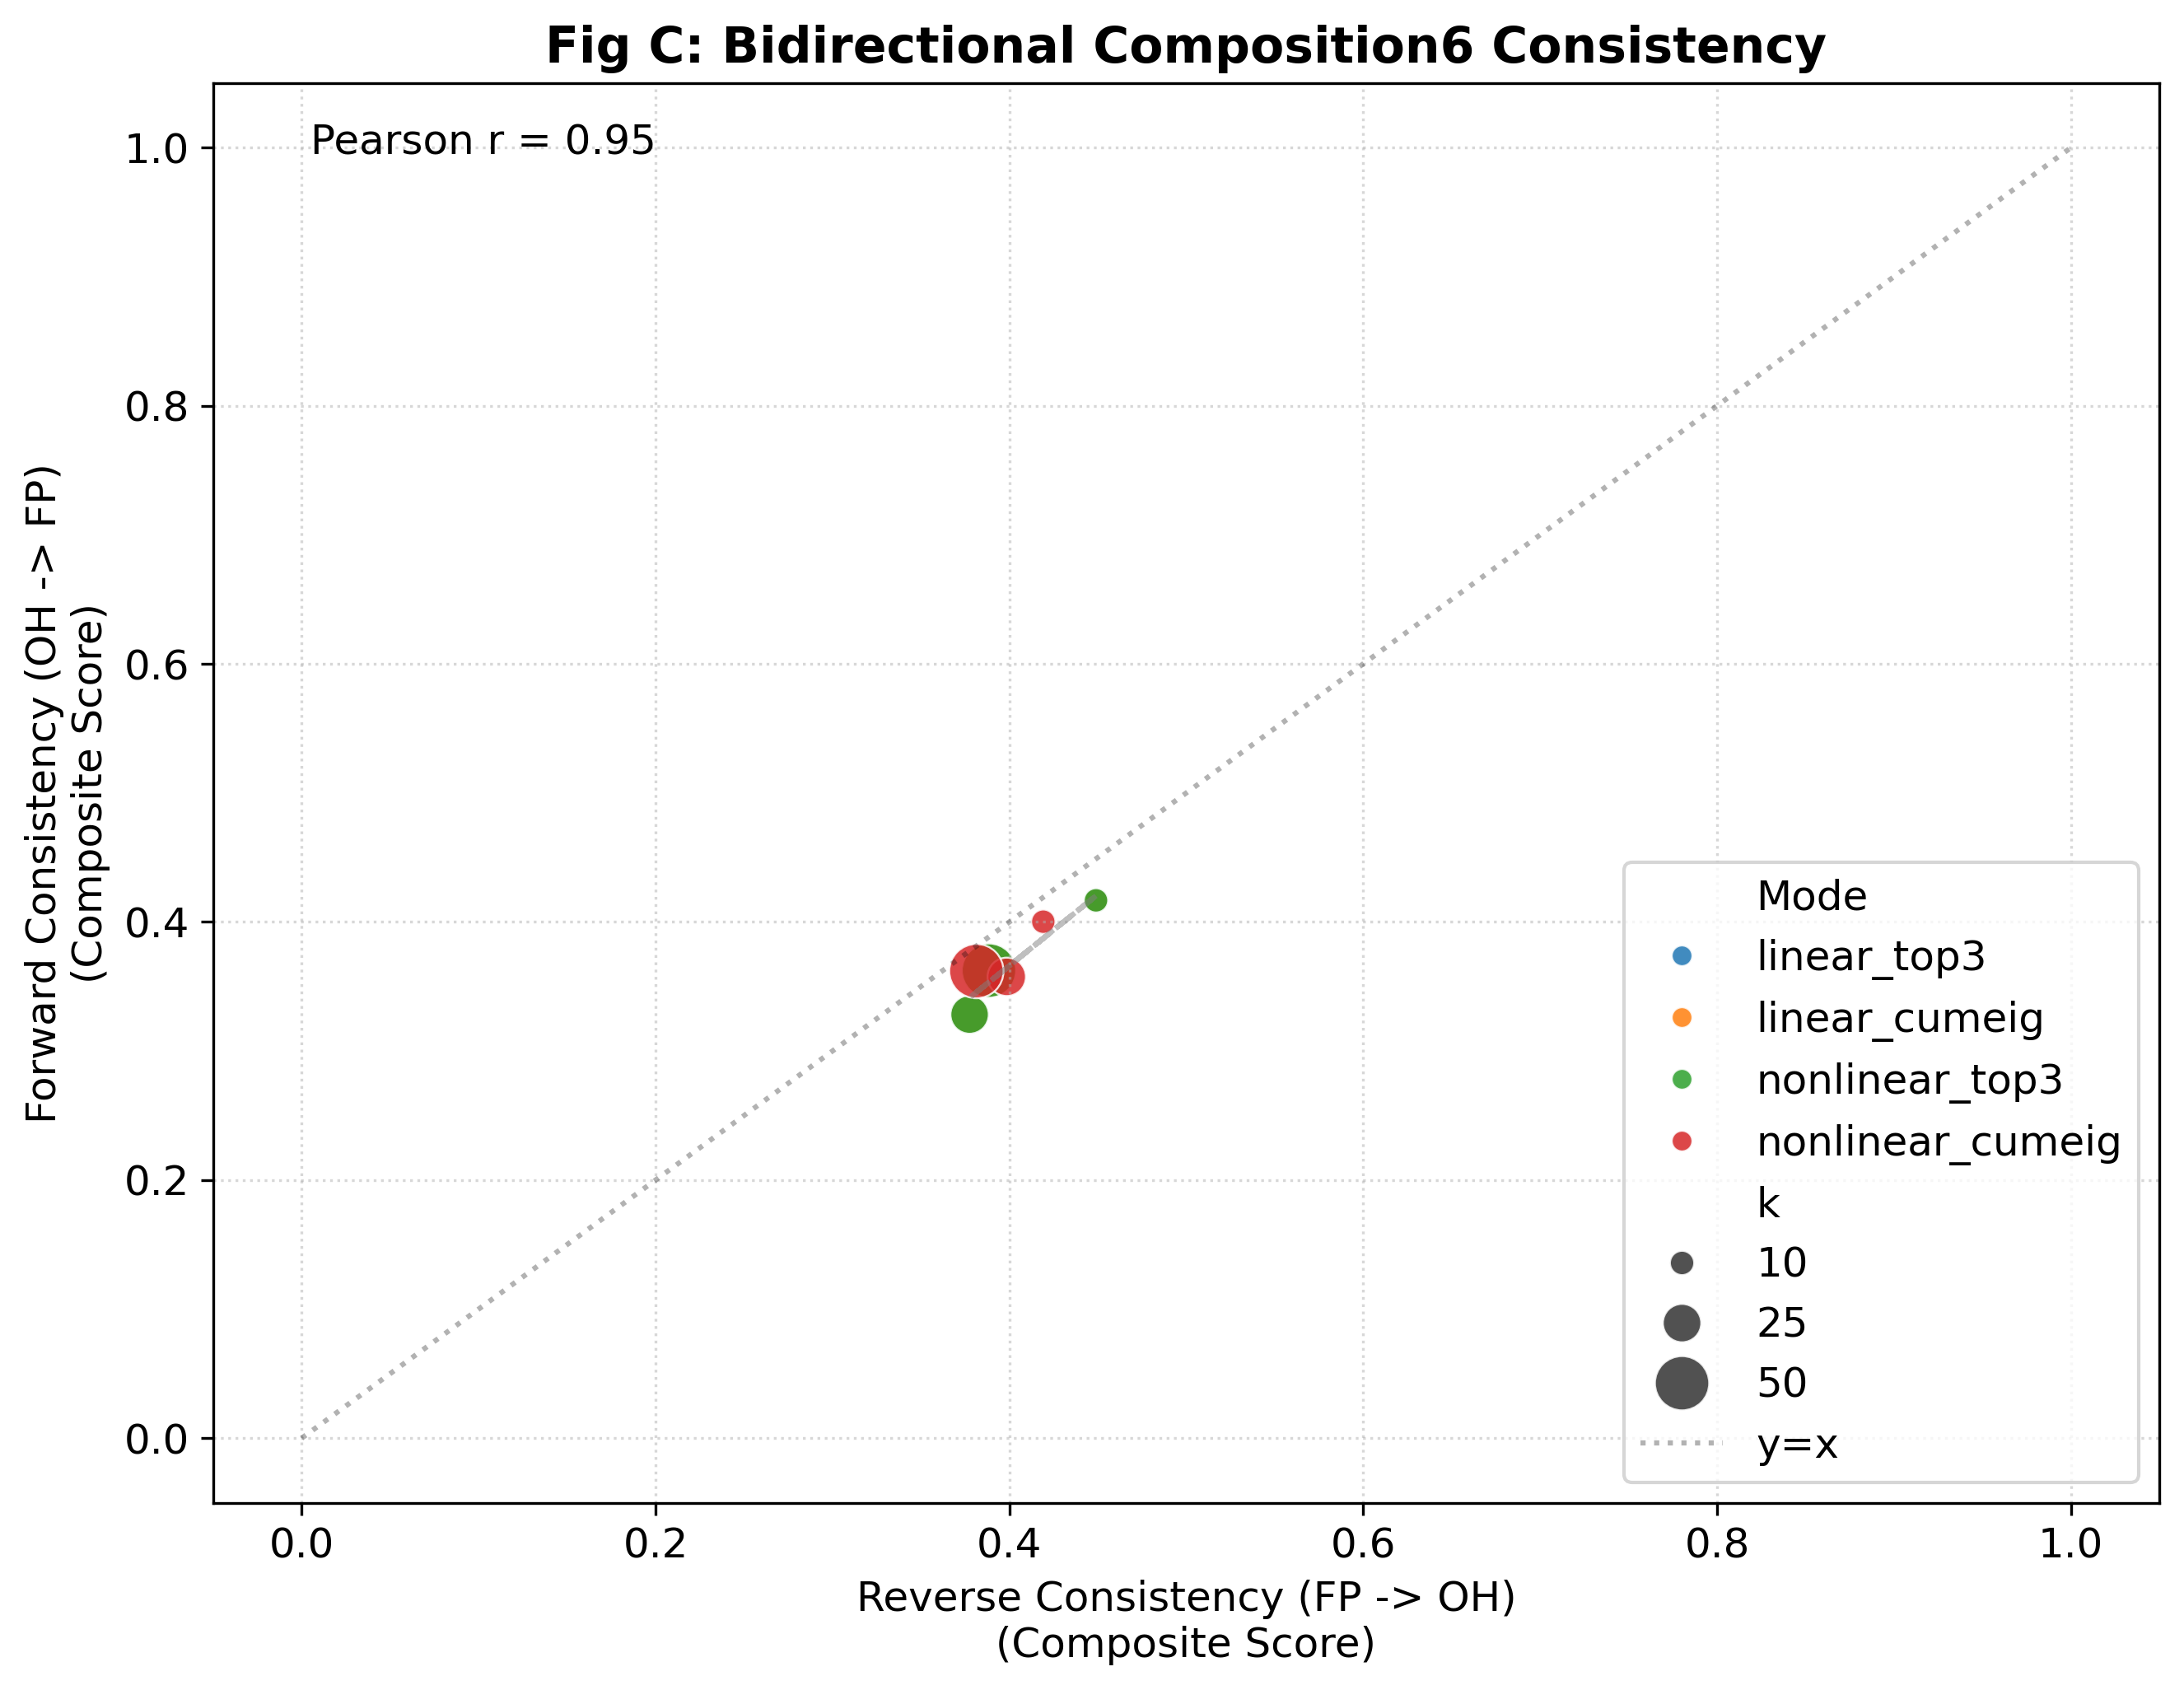

In [1]:
# STEP3.3_04_bidirectional_composition6_full_v2.py
#
# 目的: Composition6 (6指標) を双方向 (OH->FP, FP->OH) に適用し、完全に対称な評価を行う。
# 修正: 出力先フォルダの自動作成を確実に行う。
#
# 出力: Thesis_Figures/.../Validation_STEP3.3/
#       - metrics_ohfp_composition6_full.csv (全指標入り)
#       - FigC_Bidirectional_Composite_Correlation.png (対称比較図)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

# ==========================================
# 1. 設定
# ==========================================
RUN_ID = "20251130_153500"
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

# 入力ディレクトリ
SUMMARY_DIR = os.path.join(ROOT_BASE, "sub", "04_summary_STEP3.2_signlessCorr", f"run_{RUN_ID}", "samples")

# 出力先 (ここが存在しないとエラーになるので、この後で作る)
OUTPUT_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}", "Validation_STEP3.3")

# 入力ファイル
FILE_LABELS_A = "cluster_labels_matrix_samples_A_OH_plus_others_20251130_153500.csv"
FILE_LABELS_B = "cluster_labels_matrix_samples_B_FP_plus_others_20251130_153500.csv"

# プロット設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 300

print(f"Target Run ID: {RUN_ID}")
print(f"Output Directory: {OUTPUT_DIR}")

# ★ フォルダ作成 (ここが重要)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Created directory: {OUTPUT_DIR}")

# ==========================================
# 2. ヘルパー関数
# ==========================================

def safe_cos(a, b):
    len_a, len_b = len(a), len(b)
    max_len = max(len_a, len_b)
    a_pad = np.zeros(max_len); a_pad[:len_a] = a
    b_pad = np.zeros(max_len); b_pad[:len_b] = b
    if np.sum(a_pad) == 0 or np.sum(b_pad) == 0: return 0
    return cosine_similarity(a_pad.reshape(1,-1), b_pad.reshape(1,-1))[0][0]

def safe_js(p, q):
    len_p, len_q = len(p), len(q)
    max_len = max(len_p, len_q)
    p_pad = np.zeros(max_len); p_pad[:len_p] = p
    q_pad = np.zeros(max_len); q_pad[:len_q] = q
    p_norm = p_pad / (p_pad.sum() + 1e-12)
    q_norm = q_pad / (q_pad.sum() + 1e-12)
    return jensenshannon(p_norm, q_norm)

def calc_composition6(labels_grouping, labels_content):
    """
    Composition6 指標を計算する関数
    Args:
        labels_grouping: グループ分けの基準 (例: FPクラスター)
        labels_content:  中身の分布を見るラベル (例: OHラベル)
    """
    df = pd.DataFrame({'group': labels_grouping, 'content': labels_content})
    
    # 1. Purity (加重平均)
    def purity_score(g):
        if len(g) == 0: return 0
        return g.value_counts(normalize=True).max()
    
    weights = df['group'].value_counts(normalize=True)
    purities = df.groupby('group')['content'].apply(purity_score)
    weighted_purity = (purities * weights).sum()

    # 2. Entropy (加重平均)
    def entropy_score(g):
        if len(g) == 0: return 0
        probs = g.value_counts(normalize=True).values
        return -(probs * np.log(probs + 1e-12)).sum()
    
    entropies = df.groupby('group')['content'].apply(entropy_score)
    weighted_entropy = (entropies * weights).sum()

    # 3. Major Same Rate (単純一致率)
    major_same_rate = (labels_grouping == labels_content).mean()

    # 4. Cosine & 5. JS (全体分布の形状比較)
    counts_g = labels_grouping.value_counts().values.astype(float)
    counts_c = labels_content.value_counts().values.astype(float)
    cosine_val = safe_cos(counts_g, counts_c)
    js_val = safe_js(counts_g, counts_c)

    # 6. Cohesive (グループサイズの分散)
    cohesive = labels_grouping.groupby(labels_grouping).size().var()
    if np.isnan(cohesive): cohesive = 0

    return {
        "purity": weighted_purity,
        "entropy": weighted_entropy,
        "major_same_rate": major_same_rate,
        "cosine": cosine_val,
        "JS": js_val,
        "cohesive": cohesive
    }

def parse_col(c):
    p = c.split("_")
    # 例: linear_top3_k10 -> mode=linear_top3, idx=k10
    return f"{p[0]}_{p[1]}", "_".join(p[2:])

# ==========================================
# 3. データ読み込み
# ==========================================
path_A = os.path.join(SUMMARY_DIR, FILE_LABELS_A)
path_B = os.path.join(SUMMARY_DIR, FILE_LABELS_B)

if not os.path.exists(path_A) or not os.path.exists(path_B):
    raise FileNotFoundError(f"Input files not found in {SUMMARY_DIR}")

df_A = pd.read_csv(path_A)
df_B = pd.read_csv(path_B)
df_A['ID'] = df_A['ID'].astype(str)
df_B['ID'] = df_B['ID'].astype(str)

# 結合 (共通サンプルのみ)
df_merged = pd.merge(df_A, df_B, on="ID", suffixes=("_A", "_B"))
print(f"Merged Samples: {len(df_merged)}")

# ==========================================
# 4. 双方向計算ループ
# ==========================================
cols_A = [c for c in df_A.columns if c != "ID"]
results = []

print("Calculating metrics...")

for col_a in cols_A:
    col_a_merged = col_a + "_A"
    col_b_merged = col_a + "_B"
    
    # 対応する列がなければスキップ
    if col_a_merged not in df_merged.columns or col_b_merged not in df_merged.columns: continue
    
    # 欠損除去
    valid = df_merged[col_a_merged].notna() & df_merged[col_b_merged].notna()
    if valid.sum() == 0: continue
    
    oh_lab = df_merged.loc[valid, col_a_merged] # A
    fp_lab = df_merged.loc[valid, col_b_merged] # B
    
    # --- Forward (OH -> FP) ---
    fwd_metrics = calc_composition6(oh_lab, fp_lab)
    
    # --- Reverse (FP -> OH) ---
    rev_metrics = calc_composition6(fp_lab, oh_lab)
    
    # ARI (参考)
    ari = adjusted_rand_score(oh_lab, fp_lab)
    
    mode, idx_k = parse_col(col_a)
    
    # Fixed k か Auto k か判定
    if "k" in idx_k and idx_k[1:].isdigit():
        type_flag = "Fixed k"
        k_val = int(idx_k[1:])
    else:
        type_flag = "Auto k"
        k_val = len(np.unique(oh_lab))

    # 結果格納
    row = {
        "Method": col_a, "Mode": mode, "Index": idx_k, "Type": type_flag, "k": k_val,
        "ARI": ari
    }
    for k, v in fwd_metrics.items(): row[f"Fwd_{k}"] = v
    for k, v in rev_metrics.items(): row[f"Rev_{k}"] = v
    
    results.append(row)

df_res = pd.DataFrame(results)

# ==========================================
# 5. Composite Score 計算 & 図表作成
# ==========================================

def calc_composite(df, prefix):
    # 良い方向: purity, rate, cosine, cohesive
    cols_pos = ["purity", "major_same_rate", "cosine", "cohesive"]
    # 悪い方向: entropy, JS (小さいほど良い -> 1-x)
    cols_neg = ["entropy", "JS"]
    
    norm_vals = []
    for c in cols_pos:
        col = f"{prefix}_{c}"
        if col not in df.columns: continue
        mn, mx = df[col].min(), df[col].max()
        if mx - mn == 0: norm = 0.5
        else: norm = (df[col] - mn) / (mx - mn)
        norm_vals.append(norm)
        
    for c in cols_neg:
        col = f"{prefix}_{c}"
        if col not in df.columns: continue
        mn, mx = df[col].min(), df[col].max()
        if mx - mn == 0: norm = 0.5
        else: norm = (df[col] - mn) / (mx - mn)
        norm_vals.append(1 - norm) # 反転
    
    if not norm_vals: return np.nan
    return pd.concat(norm_vals, axis=1).mean(axis=1)

df_res["Fwd_Composite"] = calc_composite(df_res, "Fwd")
df_res["Rev_Composite"] = calc_composite(df_res, "Rev")

# CSV保存
out_csv = os.path.join(OUTPUT_DIR, "metrics_ohfp_composition6_full.csv")
df_res.to_csv(out_csv, index=False)
print(f"Saved CSV: {out_csv}")

# --- 図表作成 ---
print("Generating Figure...")
df_fixed = df_res[df_res["Type"] == "Fixed k"]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_fixed, x="Rev_Composite", y="Fwd_Composite", hue="Mode", size="k", sizes=(50, 250), alpha=0.85)

# 相関直線
if len(df_fixed) > 1:
    m, b = np.polyfit(df_fixed["Rev_Composite"], df_fixed["Fwd_Composite"], 1)
    plt.plot(df_fixed["Rev_Composite"], m*df_fixed["Rev_Composite"] + b, color="gray", linestyle="--", alpha=0.5)
    corr = df_fixed["Rev_Composite"].corr(df_fixed["Fwd_Composite"])
    plt.text(0.05, 0.95, f"Pearson r = {corr:.2f}", transform=plt.gca().transAxes, fontsize=12)

# 対角線 (y=x)
plt.plot([0, 1], [0, 1], color="black", linestyle=":", alpha=0.3, label="y=x")

plt.title("Fig C: Bidirectional Composition6 Consistency", fontweight="bold")
plt.xlabel("Reverse Consistency (FP -> OH)\n(Composite Score)")
plt.ylabel("Forward Consistency (OH -> FP)\n(Composite Score)")
plt.legend(loc='lower right')
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

out_fig = os.path.join(OUTPUT_DIR, "FigC_Bidirectional_Composite_Correlation.png")
plt.savefig(out_fig)
print(f"Saved Figure: {out_fig}")

print("\n✅ All Finished.")

[WARN] 'adjustText' library not found. Labels might overlap.
       To fix this, run: !pip install adjustText
Generating Improved Figure...
Saved PNG: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3/FigC_Bidirectional_Composite_Correlation_Improved.png
Saved PDF: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3/FigC_Bidirectional_Composite_Correlation_Improved.pdf


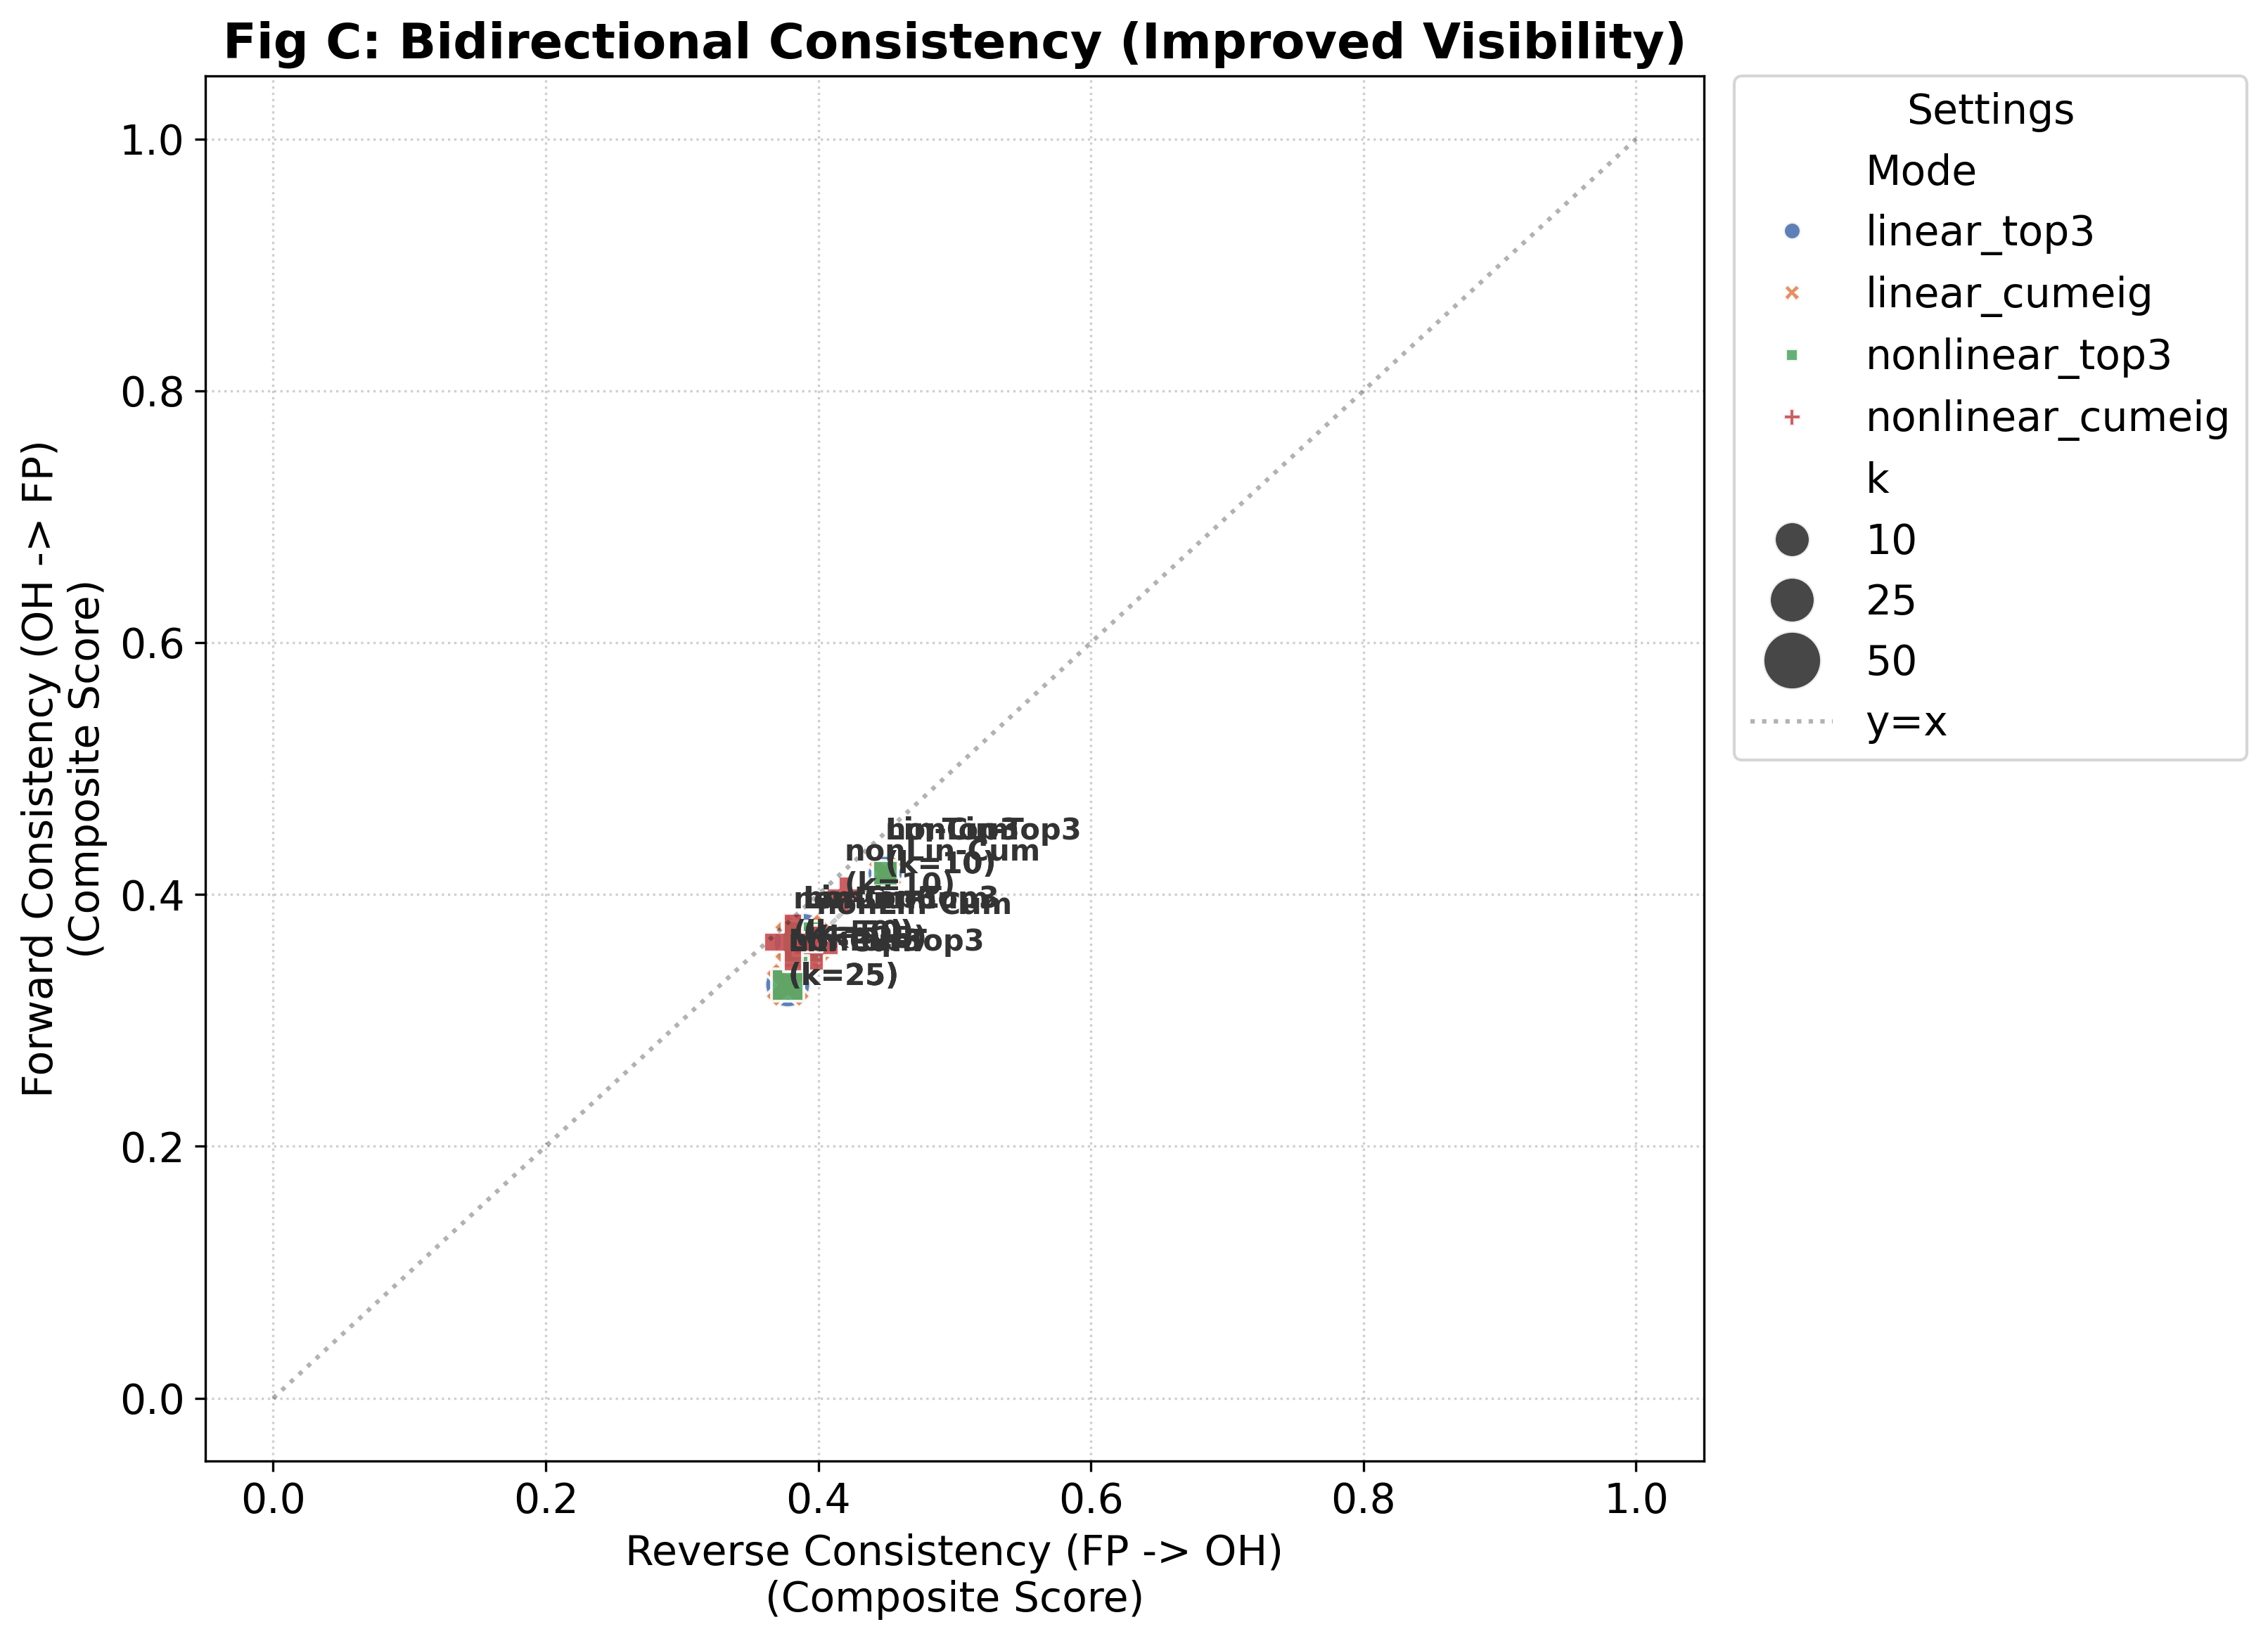

In [2]:
# STEP3.3_05_fig_c_improved.py
# 目的: Fig C (双方向整合性マップ) の視認性を劇的に改善する。
# 改善: adjustTextによる重なり回避、ラベル短縮、マーカー形状の活用

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# adjustTextのインポート (インストール確認)
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("[WARN] 'adjustText' library not found. Labels might overlap.")
    print("       To fix this, run: !pip install adjustText")

# ==========================================
# 1. 設定
# ==========================================
RUN_ID = "20251130_153500"
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

# 入出力ディレクトリ (STEP3.3_04 と同じ場所)
INPUT_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}", "Validation_STEP3.3")
OUTPUT_DIR = INPUT_DIR

# CSVファイル名
CSV_FILE = "metrics_ohfp_composition6_full.csv"

# プロット設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 300

# ==========================================
# 2. データ読み込み & 加工
# ==========================================
csv_path = os.path.join(INPUT_DIR, CSV_FILE)
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)
df_fixed = df[df['Type'] == 'Fixed k'].copy()

# --- ラベル短縮化関数 ---
def shorten_label(mode):
    # linear_top3 -> L-Top3
    # nonlinear_cumeig -> NL-Cum
    mode = mode.replace("linear", "Lin").replace("nonlinear", "NonLin")
    mode = mode.replace("top3", "Top3").replace("cumeig", "Cum")
    mode = mode.replace("_", "-")
    return mode

df_fixed['ShortMode'] = df_fixed['Mode'].apply(shorten_label)
# ラベルに k の値も含める (例: Lin-Top3 (k=10))
df_fixed['Label'] = df_fixed['ShortMode'] + "\n(k=" + df_fixed['k'].astype(str) + ")"

# ==========================================
# 3. 図表作成
# ==========================================
print("Generating Improved Figure...")

plt.figure(figsize=(11, 8)) # 横幅を広げる

# 散布図
# style=Mode を追加して、形でも区別できるようにする
sns.scatterplot(
    data=df_fixed, 
    x="Rev_Composite", 
    y="Fwd_Composite", 
    hue="Mode", 
    style="Mode", 
    size="k", 
    sizes=(150, 400), # 点をさらに大きく
    alpha=0.9,
    palette="deep"
)

# 相関直線 (全体傾向)
if len(df_fixed) > 1:
    m, b = np.polyfit(df_fixed["Rev_Composite"], df_fixed["Fwd_Composite"], 1)
    plt.plot(df_fixed["Rev_Composite"], m*df_fixed["Rev_Composite"] + b, color="gray", linestyle="--", alpha=0.4, zorder=0)

# 対角線 (y=x)
plt.plot([0, 1], [0, 1], color="black", linestyle=":", alpha=0.3, label="y=x")

# --- ラベル配置 ---
texts = []
for i, row in df_fixed.iterrows():
    # 点の座標にテキストオブジェクトを作成
    texts.append(plt.text(row['Rev_Composite'], row['Fwd_Composite'], row['Label'], 
                          fontsize=10, fontweight='bold', color='#333333'))

# --- 重なり回避実行 ---
if HAS_ADJUST_TEXT:
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
                expand_points=(1.5, 1.5)) # 点から少し離す設定

# 装飾
plt.title("Fig C: Bidirectional Consistency (Improved Visibility)", fontweight="bold")
plt.xlabel("Reverse Consistency (FP -> OH)\n(Composite Score)")
plt.ylabel("Forward Consistency (OH -> FP)\n(Composite Score)")

# 凡例を枠外に配置
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Settings")

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# 保存
out_png = os.path.join(OUTPUT_DIR, "FigC_Bidirectional_Composite_Correlation_Improved.png")
out_pdf = os.path.join(OUTPUT_DIR, "FigC_Bidirectional_Composite_Correlation_Improved.pdf")
plt.savefig(out_png)
plt.savefig(out_pdf)

print(f"Saved PNG: {out_png}")
print(f"Saved PDF: {out_pdf}")

[WARN] 'adjustText' not found. Please run: !pip install adjustText
Saved: FigC_Combined_Zoom_Final.png


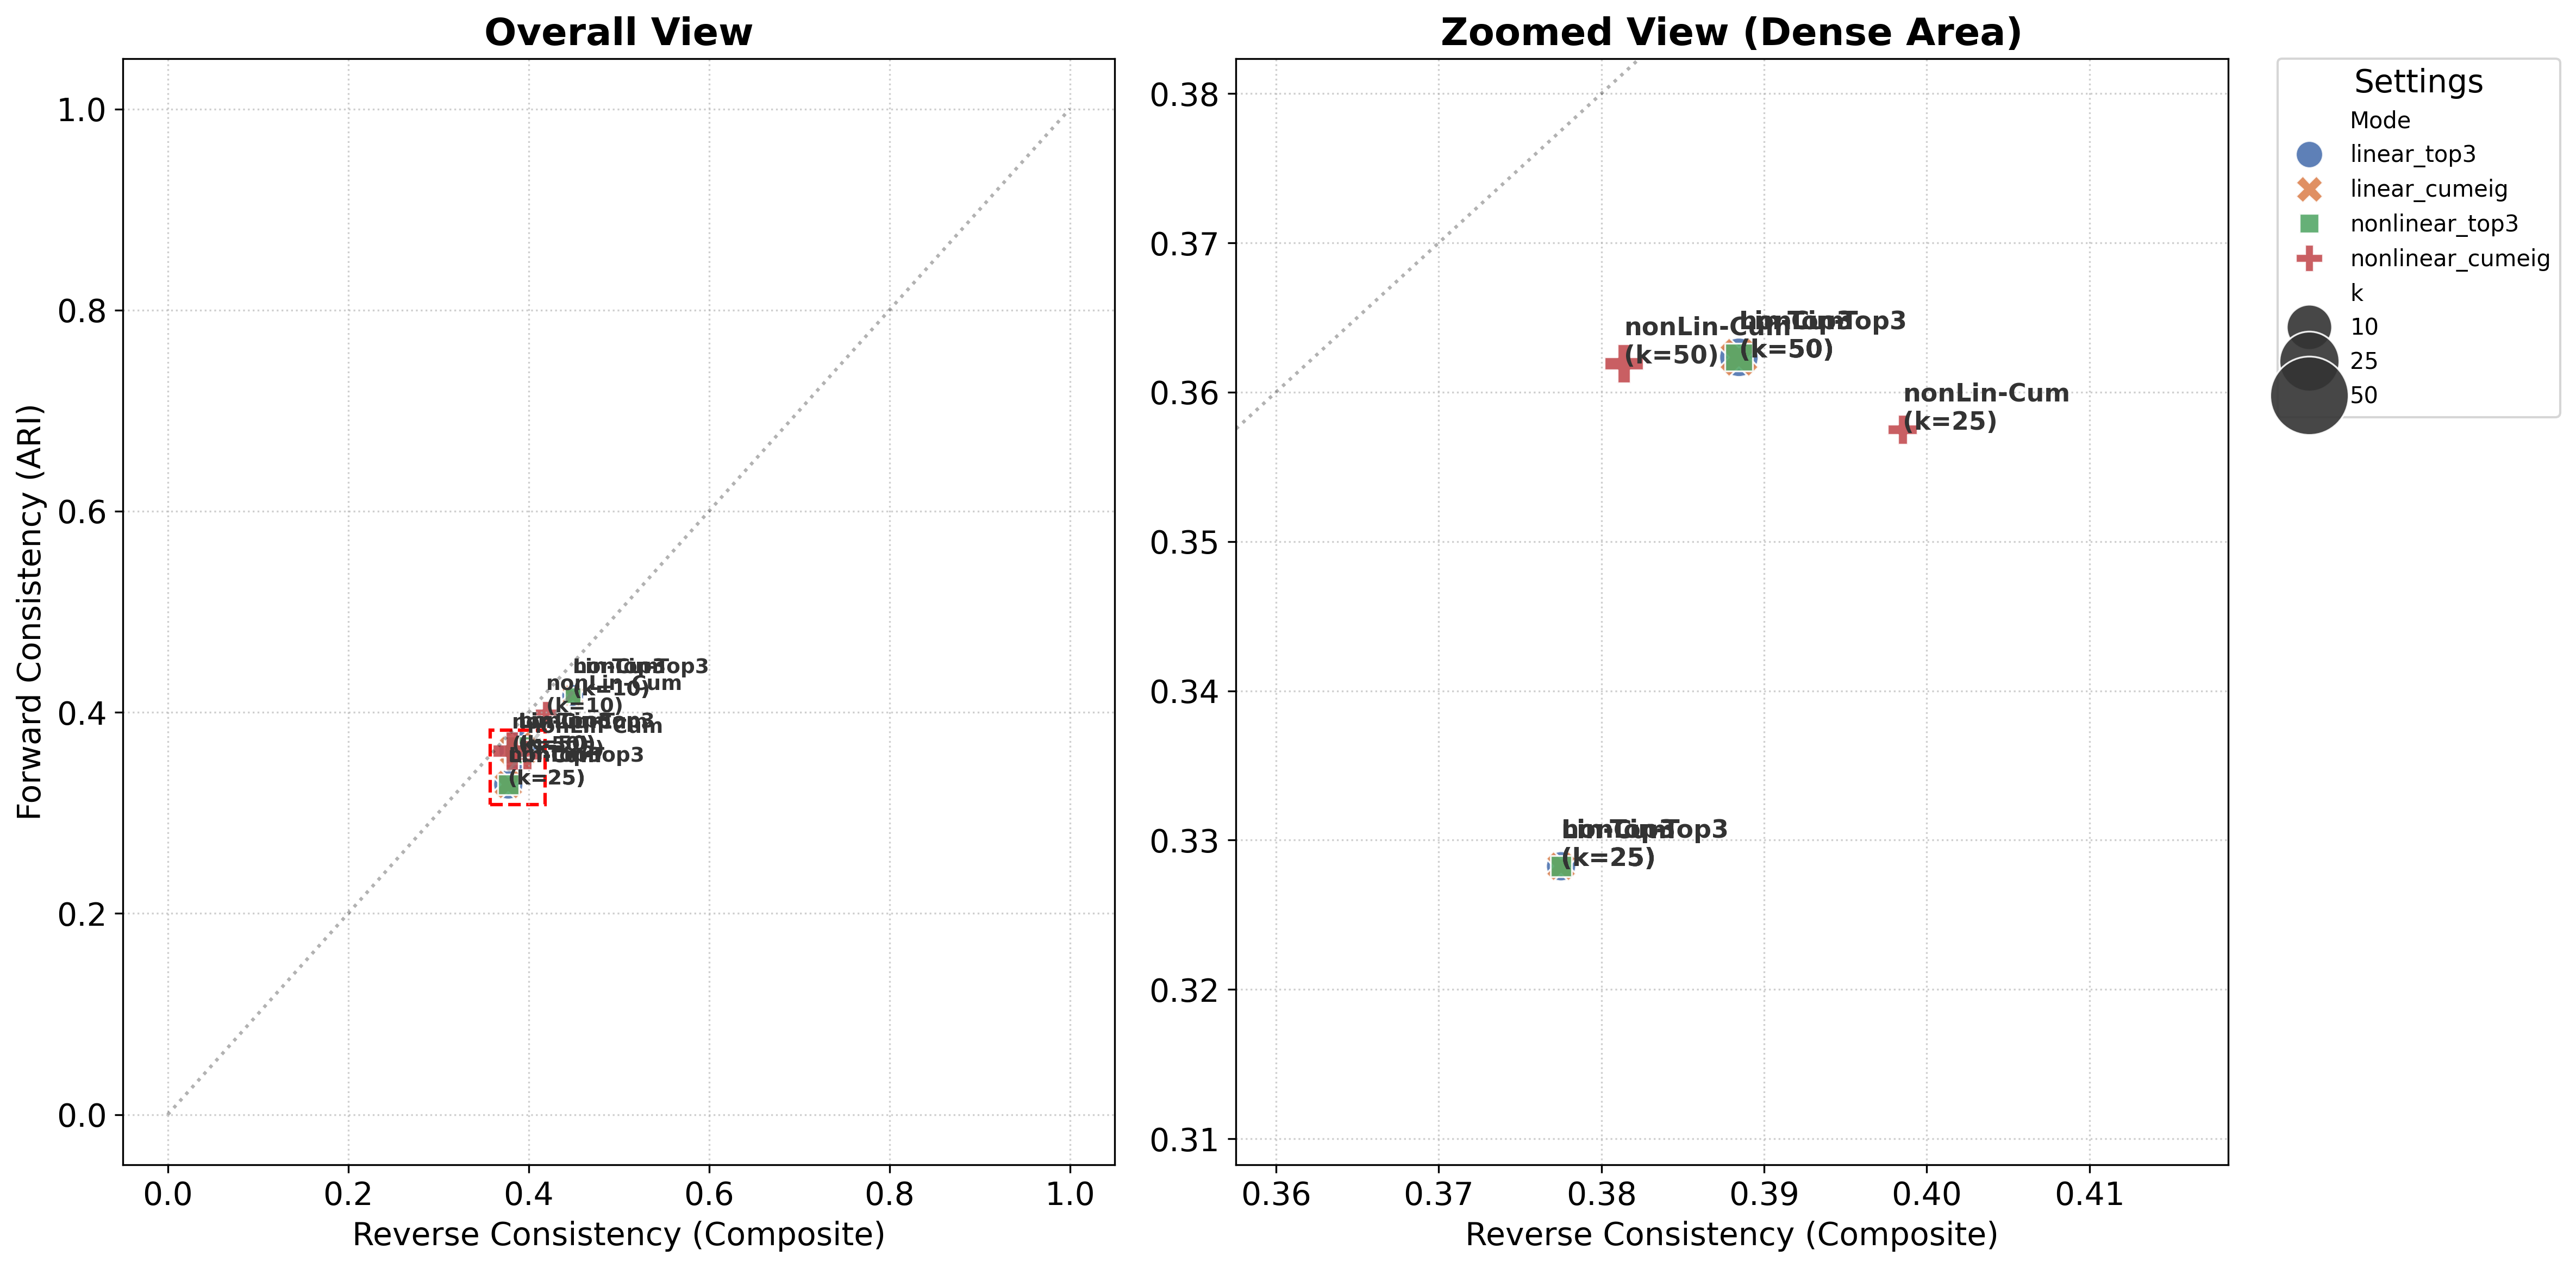

In [4]:
# STEP3.3_05_fig_c_final_adjust.py
# 目的: Fig C の視認性最終調整
# 改良:
# 1. adjustText を使ってラベルを点から離し、線で結ぶ (force_points, arrowprops)
# 2. 凡例のマーカーサイズを維持 (markerscale=2.0)
# 3. 図のデザインは維持

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle

# adjustTextのインポート
# ※ まだ入れていない場合は !pip install adjustText を実行してください
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("[WARN] 'adjustText' not found. Please run: !pip install adjustText")

# データ読み込み
# (パスは適宜書き換えてください)
csv_path = 'metrics_ohfp_composition6_full.csv'
if not os.path.exists(csv_path):
    # 絶対パスの例 (あなたの環境用)
    csv_path = '/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Validation_STEP3.3/metrics_ohfp_composition6_full.csv'

df = pd.read_csv(csv_path)
df_fixed = df[df['Type'] == 'Fixed k'].copy()

# ラベル短縮
def shorten_label(mode):
    mode = mode.replace("linear", "Lin").replace("nonlinear", "NonLin")
    mode = mode.replace("top3", "Top3").replace("cumeig", "Cum")
    mode = mode.replace("_", "-")
    return mode

df_fixed['ShortMode'] = df_fixed['Mode'].apply(shorten_label)
# ラベル作成 (例: Lin-Top3\n(k=10)) 改行を入れてコンパクトに
df_fixed['Label'] = df_fixed['ShortMode'] + "\n(k=" + df_fixed['k'].astype(str) + ")"

# 拡大エリア設定
zoom_x_min = df_fixed[df_fixed['k'] >= 25]['Rev_Composite'].min() - 0.02
zoom_x_max = df_fixed[df_fixed['k'] >= 25]['Rev_Composite'].max() + 0.02
zoom_y_min = df_fixed[df_fixed['k'] >= 25]['Fwd_Composite'].min() - 0.02
zoom_y_max = df_fixed[df_fixed['k'] >= 25]['Fwd_Composite'].max() + 0.02

# プロット作成
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) # 少し縦を広げました

# --- Plot 1: Full View ---
ax = axes[0]
sns.scatterplot(
    data=df_fixed, x="Rev_Composite", y="Fwd_Composite", 
    hue="Mode", style="Mode", size="k", sizes=(100, 300), alpha=0.9, palette="deep", ax=ax, legend=False
)
# 近似線 & 対角線
if len(df_fixed) > 1:
    m, b = np.polyfit(df_fixed["Rev_Composite"], df_fixed["Fwd_Composite"], 1)
    x_range = np.array([df_fixed['Rev_Composite'].min(), df_fixed['Rev_Composite'].max()])
    ax.plot(x_range, m*x_range + b, color="gray", linestyle="--", alpha=0.4)
ax.plot([0, 1], [0, 1], color="black", linestyle=":", alpha=0.3)

# ラベル配置 (Full)
texts = []
for i, row in df_fixed.iterrows():
    texts.append(ax.text(row['Rev_Composite'], row['Fwd_Composite'], row['Label'], 
                         fontsize=9, fontweight='bold', color='#333333'))

if HAS_ADJUST_TEXT:
    # force_points: 点から離そうとする力
    # arrowprops: 矢印（線）の設定
    adjust_text(texts, ax=ax, 
                arrowprops=dict(arrowstyle='-', color='gray', lw=1.0),
                expand_points=(1.5, 1.5))

ax.set_title("Overall View", fontweight="bold")
ax.set_xlabel("Reverse Consistency (Composite)")
ax.set_ylabel("Forward Consistency (ARI)")
ax.grid(True, linestyle=":", alpha=0.6)

# 赤枠
rect = Rectangle((zoom_x_min, zoom_y_min), zoom_x_max-zoom_x_min, zoom_y_max-zoom_y_min, 
                 linewidth=1.5, edgecolor='red', facecolor='none', linestyle='--')
ax.add_patch(rect)


# --- Plot 2: Zoomed View (拡大図) ---
ax = axes[1]
sns.scatterplot(
    data=df_fixed, x="Rev_Composite", y="Fwd_Composite", 
    hue="Mode", style="Mode", size="k", sizes=(100, 300), alpha=0.9, palette="deep", ax=ax
)
ax.plot([0, 1], [0, 1], color="black", linestyle=":", alpha=0.3)

ax.set_xlim(zoom_x_min, zoom_x_max)
ax.set_ylim(zoom_y_min, zoom_y_max)

# ラベル (Zoom)
texts_zoom = []
df_zoom = df_fixed[(df_fixed['Rev_Composite'] >= zoom_x_min) & (df_fixed['Rev_Composite'] <= zoom_x_max) &
                   (df_fixed['Fwd_Composite'] >= zoom_y_min) & (df_fixed['Fwd_Composite'] <= zoom_y_max)]

for i, row in df_zoom.iterrows():
    texts_zoom.append(ax.text(row['Rev_Composite'], row['Fwd_Composite'], row['Label'], 
                              fontsize=11, fontweight='bold', color='#333333'))

if HAS_ADJUST_TEXT:
    # ここがポイント: 点から強く離し、線で結ぶ設定
    adjust_text(texts_zoom, ax=ax, 
                force_points=2.0,     # 点からの反発力を強める
                force_text=1.0,       # テキスト同士の反発力
                expand_points=(2, 2), # 余白を確保
                arrowprops=dict(arrowstyle='-', color='black', lw=1.2)) # はっきりした線

ax.set_title("Zoomed View (Dense Area)", fontweight="bold")
ax.set_xlabel("Reverse Consistency (Composite)")
ax.set_ylabel("")
ax.grid(True, linestyle=":", alpha=0.6)

# 凡例 (大きく)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, 
          markerscale=2.0, title="Settings", fontsize=10)

plt.tight_layout()
plt.savefig("FigC_Combined_Zoom_Final.png")
plt.savefig("FigC_Combined_Zoom_Final.pdf")
print("Saved: FigC_Combined_Zoom_Final.png")

In [5]:
# STEP3.3_99_check_fp_labels.py
# 目的: FP列名が正しく ip1, ip2 等に分類されているか診断する

import pandas as pd
import re
import os

# ==========================================
# 1. 設定
# ==========================================
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"
INPUT_DATA_DIR = os.path.join(ROOT_BASE, "data", "for_MDS_STEP2")
FILE_FP_RAW = "DataMerge20211220FP_20250715.csv"

# ==========================================
# 2. 現在の変換ロジック (確認対象)
# ==========================================
FP_ROLE_MAP = {None:"in", "1":"ip1", "2":"ip2", "3":"n", "4":"p1", "5":"p2"}

# 現在の正規表現: "X" で始まり、数字が続き、オプションで ".1" ～ ".5" がつく
FP_PAT = re.compile(r"^X(?P<num>\d+)(?:\.(?P<suf>[1-5]))?$", flags=re.IGNORECASE)

def get_role_test(fp_var):
    s = str(fp_var).strip()
    m = FP_PAT.match(s)
    if not m:
        return "UNMATCHED (パターン不一致)"
    
    suf = m.group("suf")
    role = FP_ROLE_MAP.get(suf, "in") # sufがなければ "in"
    return role

# ==========================================
# 3. 診断実行
# ==========================================
path_fp = os.path.join(INPUT_DATA_DIR, FILE_FP_RAW)

if os.path.exists(path_fp):
    print(f"Loading: {FILE_FP_RAW}")
    # 最初の5行だけ読み込む（列名確認のため）
    df = pd.read_csv(path_fp, nrows=5, index_col=0)
    cols = df.columns.tolist()
    
    print(f"\nTotal Columns: {len(cols)}")
    print(f"Sample Columns (Head 10): {cols[:10]}")
    
    # 全列に対してテスト
    results = [get_role_test(c) for c in cols]
    counts = pd.Series(results).value_counts()
    
    print("\n--- [診断結果] 分類内訳 ---")
    print(counts)
    
    # 失敗例があれば表示
    if "UNMATCHED (パターン不一致)" in counts:
        print("\n--- [警告] パターン不一致の例 (Top 5) ---")
        unmatched = [c for c, r in zip(cols, results) if r == "UNMATCHED (パターン不一致)"]
        print(unmatched[:5])
        
        print("\n--> 対処法: 列名に 'X' がついていない、または '.' 以外の区切り文字が使われている可能性があります。")
else:
    print(f"[ERROR] File not found: {path_fp}")

Loading: DataMerge20211220FP_20250715.csv

Total Columns: 1096
Sample Columns (Head 10): ['Lay2thickness', 'Aonsetp1Mfilm', 'MwkDap1M', 'LUMOp1M', 'MnkDap1M', 'VolRatioS1', 'Mmonomerp1M', 'Lay6thickness', 'HOMOp1M', 'ALthickness']

--- [診断結果] 分類内訳 ---
in                     166
ip1                    166
ip2                    166
p1                     166
n                      166
p2                     166
UNMATCHED (パターン不一致)    100
Name: count, dtype: int64

--- [警告] パターン不一致の例 (Top 5) ---
['Lay2thickness', 'Aonsetp1Mfilm', 'MwkDap1M', 'LUMOp1M', 'MnkDap1M']

--> 対処法: 列名に 'X' がついていない、または '.' 以外の区切り文字が使われている可能性があります。


Target Run ID: 20251130_153500
Merged Samples: 1046

--- Generating Figures ---

✅ All Finished. Symmetric Analysis Complete!


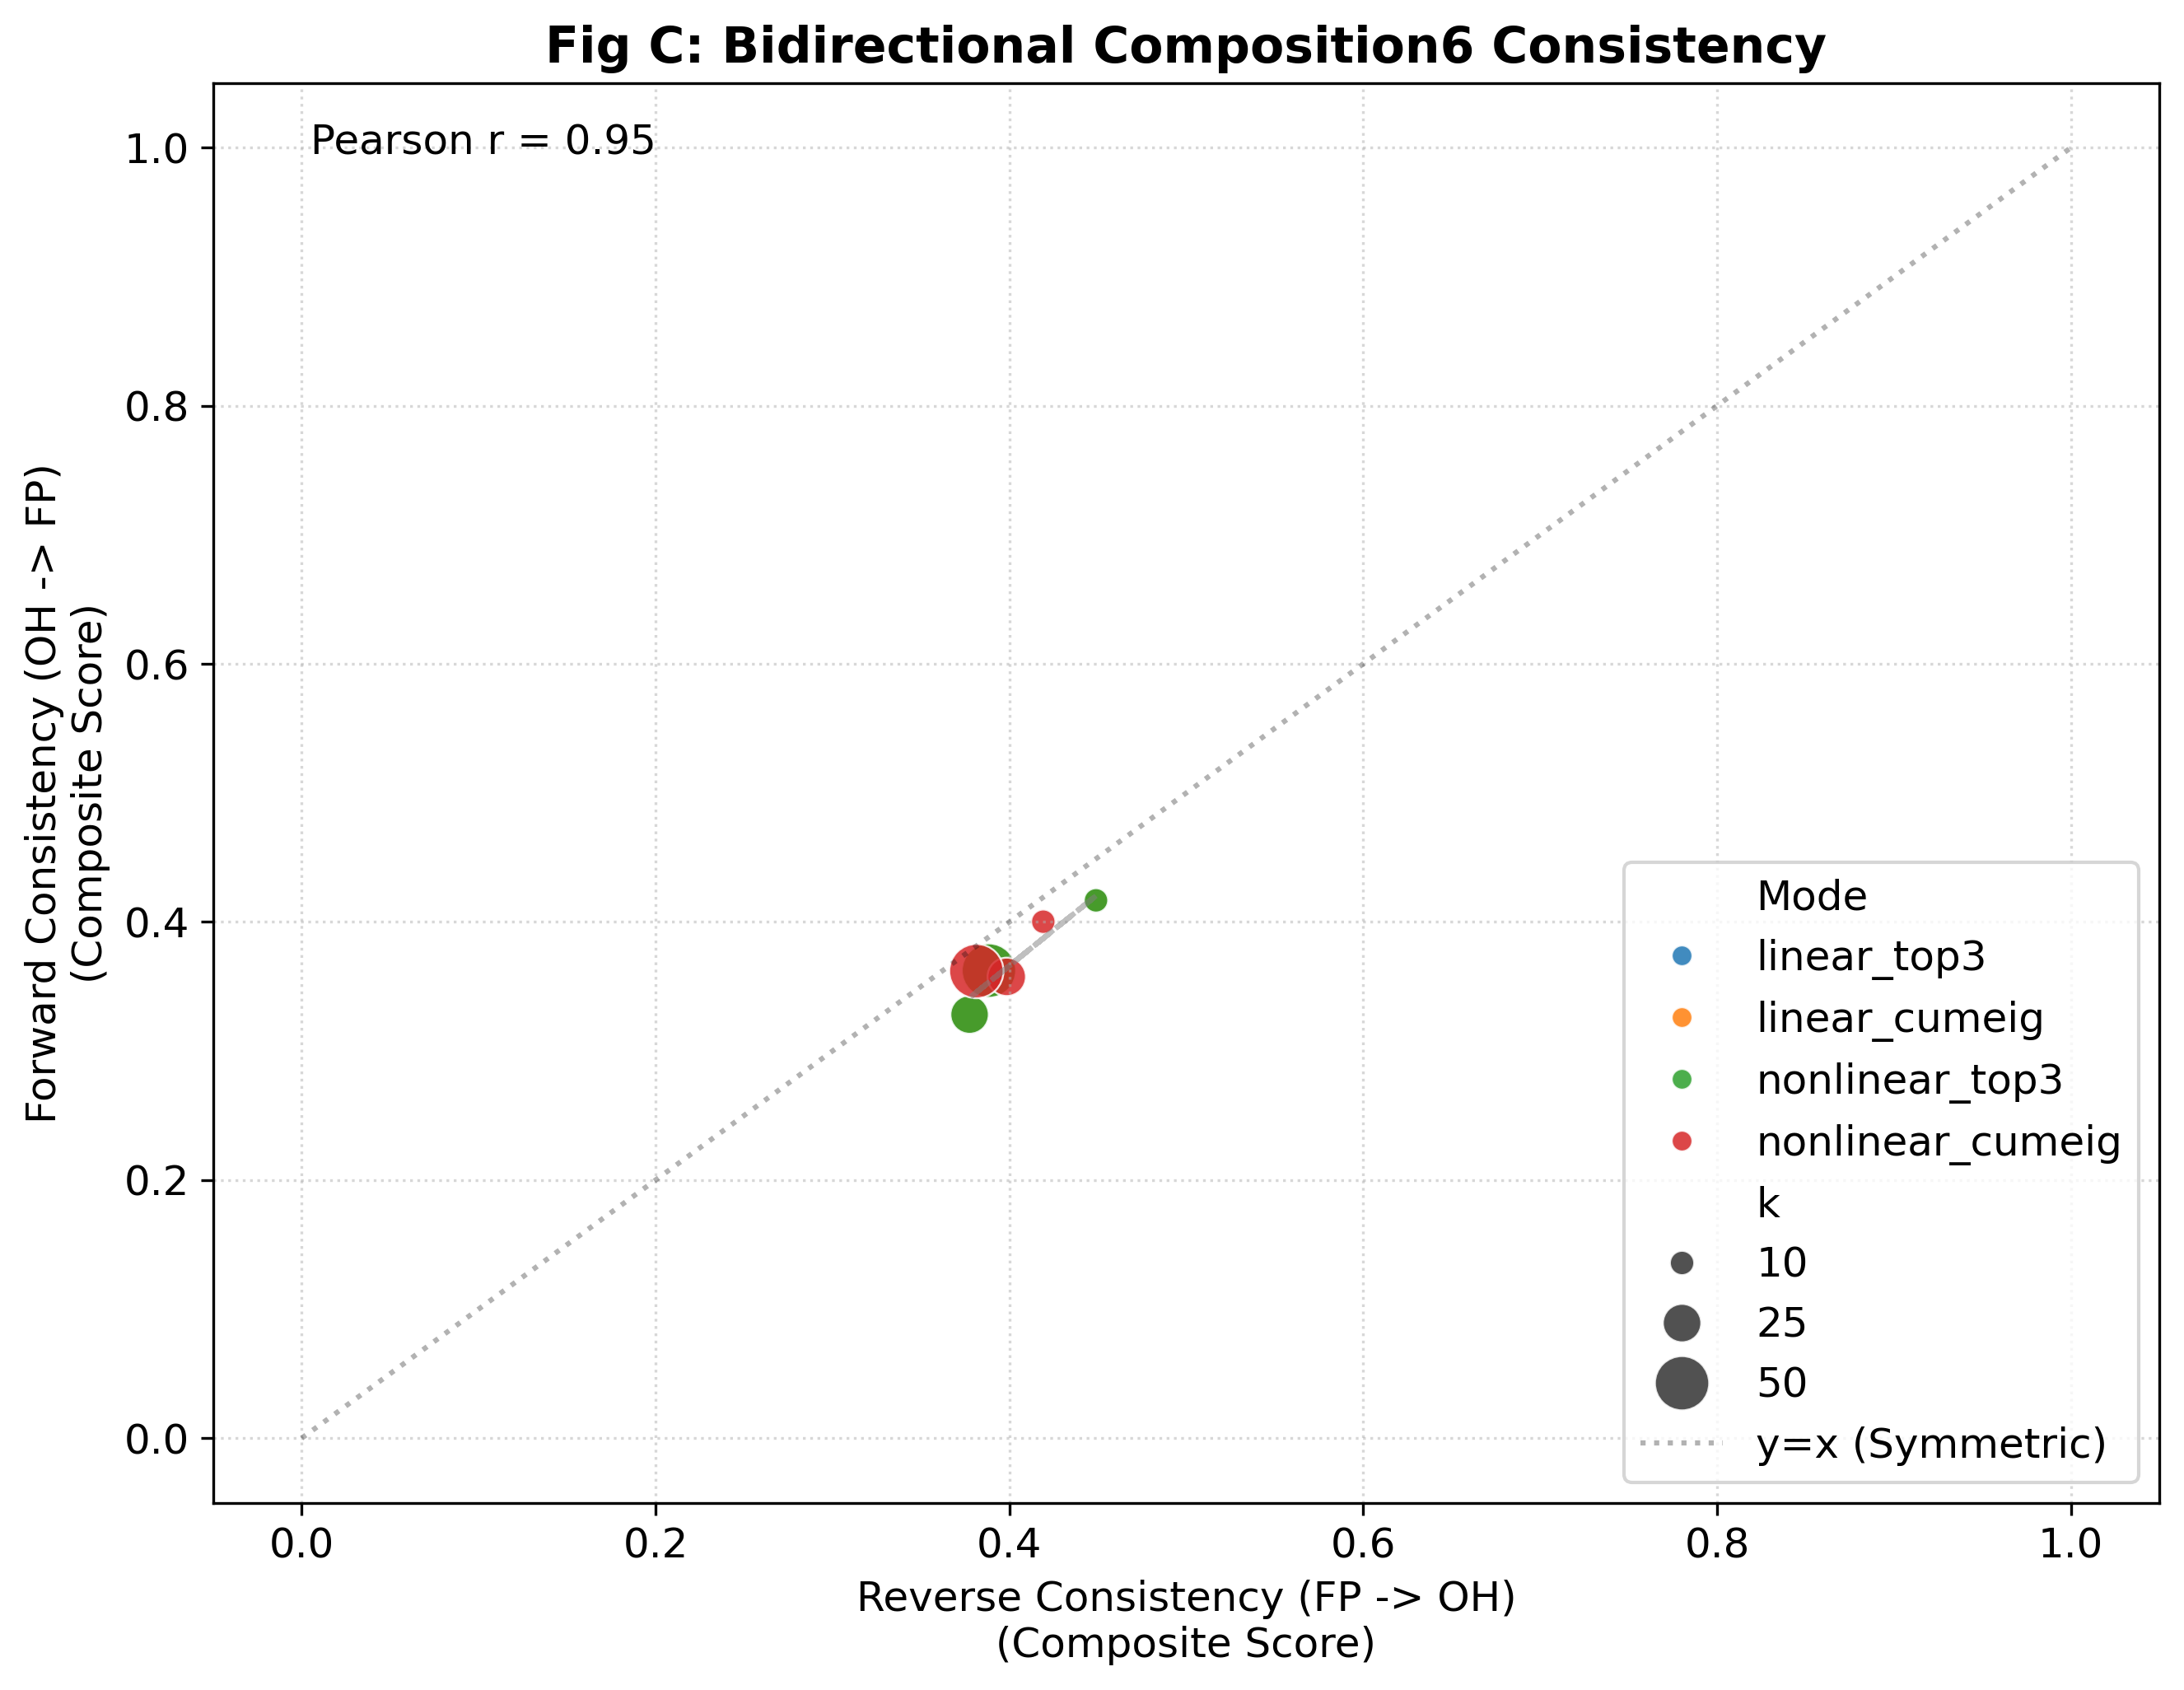

In [6]:
# STEP3.3_04_bidirectional_composition6_full.py
#
# 目的: Composition6 (6指標) を双方向 (OH->FP, FP->OH) に適用し、
#       完全に対称な評価を行う。
#
# 出力: Thesis_Figures/.../Validation_STEP3.3/
#       - metrics_ohfp_composition6_full.csv (全指標入り)
#       - FigC_Bidirectional_Composite_Correlation.png (対称比較図)
#       - FigD_Method_Robustness_Composite.png

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

# ==========================================
# 1. 設定
# ==========================================
RUN_ID = "20251130_153500"
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

SUMMARY_DIR = os.path.join(ROOT_BASE, "sub", "04_summary_STEP3.2_signlessCorr", f"run_{RUN_ID}", "samples")
OUTPUT_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}", "Validation_STEP3.3")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILE_LABELS_A = "cluster_labels_matrix_samples_A_OH_plus_others_20251130_153500.csv"
FILE_LABELS_B = "cluster_labels_matrix_samples_B_FP_plus_others_20251130_153500.csv"

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 300

print(f"Target Run ID: {RUN_ID}")

# ==========================================
# 2. ヘルパー関数
# ==========================================

def safe_cos(a, b):
    # 長さ合わせ
    len_a, len_b = len(a), len(b)
    max_len = max(len_a, len_b)
    a_pad = np.zeros(max_len); a_pad[:len_a] = a
    b_pad = np.zeros(max_len); b_pad[:len_b] = b
    if np.sum(a_pad) == 0 or np.sum(b_pad) == 0: return 0
    return cosine_similarity(a_pad.reshape(1,-1), b_pad.reshape(1,-1))[0][0]

def safe_js(p, q):
    len_p, len_q = len(p), len(q)
    max_len = max(len_p, len_q)
    p_pad = np.zeros(max_len); p_pad[:len_p] = p
    q_pad = np.zeros(max_len); q_pad[:len_q] = q
    p_norm = p_pad / (p_pad.sum() + 1e-12)
    q_norm = q_pad / (q_pad.sum() + 1e-12)
    return jensenshannon(p_norm, q_norm)

def calc_composition6(labels_grouping, labels_content):
    """
    Composition6 指標を計算する関数
    Args:
        labels_grouping: グループ分けの基準となるラベル (例: FPクラスター)
        labels_content:  中身の分布を見るラベル (例: OHラベル)
    Returns:
        dict: 6指標の値
    """
    # 1. Purity (最大多数派の割合)
    # 各グループごとのpurityを計算し、その加重平均をとるのが一般的だが、
    # 提供コードの仕様「全体の中で最も支配的な割合」に合わせるなら単純な value_counts().max()
    # しかし「クラスターごとの純度」を評価したいのであれば、groupbyして平均すべき。
    # ★ここでは提供コードの思想「分布全体のピーク性」を踏襲しつつ、
    #   より適切な「グループごとの純度の加重平均」を採用します（クラスタリング評価として標準的）
    
    df = pd.DataFrame({'group': labels_grouping, 'content': labels_content})
    
    # グループごとの純度
    def purity_score(g):
        if len(g) == 0: return 0
        return g.value_counts(normalize=True).max()
    
    purities = df.groupby('group')['content'].apply(purity_score)
    weights = df['group'].value_counts(normalize=True)
    weighted_purity = (purities * weights).sum()

    # 2. Entropy (エントロピーの加重平均)
    def entropy_score(g):
        if len(g) == 0: return 0
        probs = g.value_counts(normalize=True).values
        return -(probs * np.log(probs + 1e-12)).sum()
    
    entropies = df.groupby('group')['content'].apply(entropy_score)
    weighted_entropy = (entropies * weights).sum()

    # 3. Major Same Rate (単純一致率)
    # ※これはラベルIDが同じかどうかなので、方向によらず同じ値になる
    major_same_rate = (labels_grouping == labels_content).mean()

    # 4. Cosine & 5. JS (分布形状の類似度)
    # 全体の頻度分布同士を比較
    counts_g = labels_grouping.value_counts().values.astype(float)
    counts_c = labels_content.value_counts().values.astype(float)
    cosine_val = safe_cos(counts_g, counts_c)
    js_val = safe_js(counts_g, counts_c)

    # 6. Cohesive (グループごとのサイズ分散)
    # これは grouping 側の性質
    cohesive = labels_grouping.groupby(labels_grouping).size().var()
    if np.isnan(cohesive): cohesive = 0

    return {
        "purity": weighted_purity,
        "entropy": weighted_entropy,
        "major_same_rate": major_same_rate,
        "cosine": cosine_val,
        "JS": js_val,
        "cohesive": cohesive
    }

# ==========================================
# 3. データ読み込み
# ==========================================
path_A = os.path.join(SUMMARY_DIR, FILE_LABELS_A)
path_B = os.path.join(SUMMARY_DIR, FILE_LABELS_B)

df_A = pd.read_csv(path_A)
df_B = pd.read_csv(path_B)
df_A['ID'] = df_A['ID'].astype(str)
df_B['ID'] = df_B['ID'].astype(str)
df_merged = pd.merge(df_A, df_B, on="ID", suffixes=("_A", "_B"))
print(f"Merged Samples: {len(df_merged)}")

# ==========================================
# 4. 双方向計算ループ
# ==========================================
cols_A = [c for c in df_A.columns if c != "ID"]
results = []

def parse_col(c):
    p = c.split("_")
    return f"{p[0]}_{p[1]}", "_".join(p[2:])

for col_a in cols_A:
    col_a_merged = col_a + "_A"
    col_b_merged = col_a + "_B"
    if col_a_merged not in df_merged.columns or col_b_merged not in df_merged.columns: continue
    
    valid = df_merged[col_a_merged].notna() & df_merged[col_b_merged].notna()
    if valid.sum() == 0: continue
    
    oh_lab = df_merged.loc[valid, col_a_merged] # A
    fp_lab = df_merged.loc[valid, col_b_merged] # B
    
    # --- Forward (OH -> FP) ---
    # OHでグルーピングしたとき、FPはまとまっているか？
    fwd_metrics = calc_composition6(oh_lab, fp_lab)
    
    # --- Reverse (FP -> OH) ---
    # FPでグルーピングしたとき、OHはまとまっているか？
    rev_metrics = calc_composition6(fp_lab, oh_lab)
    
    # ラベル比較 (ARI) も一応計算
    ari = adjusted_rand_score(oh_lab, fp_lab)
    
    mode, idx_k = parse_col(col_a)
    type_flag = "Fixed k" if "k" in idx_k and idx_k[1:].isdigit() else "Auto k"
    k_val = int(idx_k[1:]) if type_flag == "Fixed k" else len(np.unique(oh_lab))

    # 結果格納 (キーに Fwd_ / Rev_ をつける)
    row = {
        "Method": col_a, "Mode": mode, "Index": idx_k, "Type": type_flag, "k": k_val,
        "ARI": ari
    }
    for k, v in fwd_metrics.items(): row[f"Fwd_{k}"] = v
    for k, v in rev_metrics.items(): row[f"Rev_{k}"] = v
    
    results.append(row)

df_res = pd.DataFrame(results)

# ==========================================
# 5. Composite Score 計算 & 図表作成
# ==========================================

# 正規化 & 合成関数
def calc_composite(df, prefix):
    # 良い方向: purity, rate, cosine, cohesive
    # 悪い方向: entropy, JS
    cols_pos = ["purity", "major_same_rate", "cosine", "cohesive"]
    cols_neg = ["entropy", "JS"]
    
    norm_vals = []
    for c in cols_pos:
        col = f"{prefix}_{c}"
        mn, mx = df[col].min(), df[col].max()
        norm = (df[col] - mn) / (mx - mn + 1e-12)
        norm_vals.append(norm)
        
    for c in cols_neg:
        col = f"{prefix}_{c}"
        mn, mx = df[col].min(), df[col].max()
        norm = (df[col] - mn) / (mx - mn + 1e-12)
        norm_vals.append(1 - norm) # 反転
    
    return pd.concat(norm_vals, axis=1).mean(axis=1)

df_res["Fwd_Composite"] = calc_composite(df_res, "Fwd")
df_res["Rev_Composite"] = calc_composite(df_res, "Rev")

# CSV保存
df_res.to_csv(os.path.join(OUTPUT_DIR, "metrics_ohfp_composition6_full.csv"), index=False)

# --- 図表作成 ---
print("\n--- Generating Figures ---")
df_fixed = df_res[df_res["Type"] == "Fixed k"]

# Fig C (改): Forward Composite vs Reverse Composite
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_fixed, x="Rev_Composite", y="Fwd_Composite", hue="Mode", size="k", sizes=(50, 250), alpha=0.85)

# 相関直線
if len(df_fixed) > 1:
    m, b = np.polyfit(df_fixed["Rev_Composite"], df_fixed["Fwd_Composite"], 1)
    plt.plot(df_fixed["Rev_Composite"], m*df_fixed["Rev_Composite"] + b, color="gray", linestyle="--", alpha=0.5)
    corr = df_fixed["Rev_Composite"].corr(df_fixed["Fwd_Composite"])
    plt.text(0.05, 0.95, f"Pearson r = {corr:.2f}", transform=plt.gca().transAxes, fontsize=12)

# 対角線 (y=x) を引くと、「どちら向きの整合性が強いか」がわかる
plt.plot([0, 1], [0, 1], color="black", linestyle=":", alpha=0.3, label="y=x (Symmetric)")

plt.title("Fig C: Bidirectional Composition6 Consistency", fontweight="bold")
plt.xlabel("Reverse Consistency (FP -> OH)\n(Composite Score)")
plt.ylabel("Forward Consistency (OH -> FP)\n(Composite Score)")
plt.legend(loc='lower right')
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "FigC_Bidirectional_Composite_Correlation.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "FigC_Bidirectional_Composite_Correlation.pdf"))

print("\n✅ All Finished. Symmetric Analysis Complete!")